# Synthetic Li atomic-fraction profiles for circular electrodes

This notebook generates spatial Li atomic-fraction profiles for graphite and NMC electrodes. The general construction is for a compound $\mathrm{Li}_lX_x$: build a Li fraction whose integrated Li-to-$X$ atom ratio is $l/x$, then divide the remaining atomic fraction among the fixed constituents of $X$. The depth coordinate is total areal density in units of $10^{15}$ atoms/cm$^2$, with a sample thickness of 100,000 such units, so $n_i\,dz$ gives the areal density of species $i$.


## General construction

For a compound $\mathrm{Li}_lX_x$, let $n_{\mathrm{Li}}(r,\theta,z)$ be the local Li atomic fraction and let $1-n_{\mathrm{Li}}$ be the fraction belonging to $X$. The goal is

$$
\frac{N_{\mathrm{Li}}}{N_X}
=\frac{\int n_{\mathrm{Li}}\,dA\,dz}
{\int(1-n_{\mathrm{Li}})\,dA\,dz}
=\frac{l}{x}.
$$

Here $z$ is total areal density in units of $10^{15}$ atoms/cm$^2$ and spans the sample thickness of 100,000 units. Thus $n_i\,dz$ is the areal density of element $i$ in a depth interval; the common area and depth measure cancels in the ratio.

Construct a separable Li profile

$$
n_{\mathrm{Li}}(r,\theta,z)=A_l(r,\theta)D_l(z),
$$

with unit-mean modulation factors

$$
A_l(r,\theta)=m_l[1+\alpha_r f_r(r,\theta)],
\qquad
D_l(z)=1+\alpha_z f_z(z),
\qquad
m_l=\frac{l}{l+x}.
$$

The modes have zero mean under the area and areal-depth measures:

$$
\int f_r\,dA=0,
\qquad
\int f_z\,dz=0.
$$

For a separable cylindrical domain, this gives $\langle n_{\mathrm{Li}}\rangle=m_l$ and therefore $N_{\mathrm{Li}}/N_X=l/x$. Choose the amplitudes so $0\leq A_lD_l\leq1$ everywhere. For the anode and cathode examples, the code also caps the amplitudes as needed to keep local stoichiometry within the selected endpoint range; this cap does not change the mean profile. The remaining fraction is assigned to the elements of $X$ in their fixed proportions.

## Elemental atomic fractions

For graphite, $X=\mathrm{C}_6$ and $x=6$:

$$
n_{\mathrm{Li}}=\frac{l}{l+6},
\qquad
n_{\mathrm C}=1-n_{\mathrm{Li}}=\frac{6}{l+6}.
$$

For NMC, $X=\mathrm{Ni}_a\mathrm{Mn}_b\mathrm{Co}_c\mathrm O_2$, with $a+b+c=1$ and $x=3$:

$$
n_{\mathrm{Li}}=\frac{l}{l+3},\quad
n_{\mathrm{Ni}}=\frac{a}{3}(1-n_{\mathrm{Li}}),\quad
n_{\mathrm{Mn}}=\frac{b}{3}(1-n_{\mathrm{Li}}),\quad
n_{\mathrm{Co}}=\frac{c}{3}(1-n_{\mathrm{Li}}),\quad
n_{\mathrm O}=\frac{2}{3}(1-n_{\mathrm{Li}}).
$$

The code below applies this same profile construction to both electrodes. For the synthetic SOC mapping, $l$ varies linearly between the configured endpoints; this is a chosen mapping, not a cell-specific SOC calibration.


In [47]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


NMC_COMPOSITIONS = {
    "NMC111": (1 / 3, 1 / 3, 1 / 3),
    "NMC622": (0.6, 0.2, 0.2),
    "NMC811": (0.8, 0.1, 0.1),
}


@dataclass(frozen=True)
class CircularElectrodeGeometry:
    """Circular area and total-areal-density depth coordinate.

    R is in mm. areal_depth_max is in units of 1e15 atoms/cm^2.
    """

    R: float = 5.0
    areal_depth_max: float = 100_000.0
    Nx: int = 101
    Ny: int = 101
    Nz: int = 51

    def __post_init__(self) -> None:
        if self.R <= 0 or self.areal_depth_max <= 0:
            raise ValueError("R and areal_depth_max must be positive")
        if min(self.Nx, self.Ny, self.Nz) < 2:
            raise ValueError("Nx, Ny and Nz must each be at least 2")

    def spatial_basis(self):
        # Use cell centers so every active sample represents equal dA dz_A.
        # z_A is measured in units of 1e15 atoms/cm^2.
        dx = 2.0 * self.R / self.Nx
        dy = 2.0 * self.R / self.Ny
        x_grid = -self.R + (np.arange(self.Nx) + 0.5) * dx
        y_grid = -self.R + (np.arange(self.Ny) + 0.5) * dy
        dz_a = self.areal_depth_max / self.Nz
        z_grid = (np.arange(self.Nz) + 0.5) * dz_a
        X, Y = np.meshgrid(x_grid, y_grid, indexing="xy")
        radius = np.hypot(X, Y)
        active_xy = radius <= self.R

        # Center each sampled mode under the same discrete integration
        # measure used below, then scale it to have maximum magnitude one.
        f_r = 1.0 - 2.0 * (radius / self.R) ** 2
        f_r[active_xy] -= f_r[active_xy].mean()
        f_r /= np.max(np.abs(f_r[active_xy]))
        f_r[~active_xy] = 0.0
        f_z = 1.0 - 2.0 * z_grid / self.areal_depth_max
        f_z -= f_z.mean()
        f_z /= np.max(np.abs(f_z))

        mask = np.broadcast_to(active_xy[None, :, :], (self.Nz, self.Ny, self.Nx))
        dA_dzA = float(dx * dy * dz_a)
        return x_grid, y_grid, z_grid, mask, f_r, f_z, dA_dzA


@dataclass
class ElectrodeResult:
    fields: dict[str, np.ndarray]
    x_grid: np.ndarray
    y_grid: np.ndarray
    z_grid: np.ndarray
    areal_depth_max: float
    mask: np.ndarray
    local_lithiation: np.ndarray
    f_r: np.ndarray
    f_z: np.ndarray
    dA_dzA: float
    electrode: str
    chemistry: str
    requested_soc: float


def heterogeneity_envelope(eta: float) -> float:
    if not 0.0 <= eta <= 1.0:
        raise ValueError("SOC eta must lie in [0, 1]")
    return 4.0 * eta * (1.0 - eta)


def build_li_fraction_profile(
    mean_li_fraction: float,
    f_r: np.ndarray,
    f_z: np.ndarray,
    eta: float,
    kappa: float,
    w_r: float,
    w_z: float,
    fraction_bounds: tuple[float, float],
    mask: np.ndarray,
) -> np.ndarray:
    """Build n_Li=A_l(r,theta)D_l(z) with the requested integrated ratio."""
    if not 0.0 <= mean_li_fraction <= 1.0:
        raise ValueError("mean_li_fraction must lie in [0, 1]")
    lower, upper = fraction_bounds
    if not 0.0 <= lower <= mean_li_fraction <= upper <= 1.0:
        raise ValueError("fraction_bounds must contain mean_li_fraction within [0, 1]")
    if kappa < 0 or w_r < 0 or w_z < 0 or w_r + w_z <= 0:
        raise ValueError("kappa must be nonnegative; weights must be nonnegative and not both zero")

    envelope = heterogeneity_envelope(eta)
    alpha_r = kappa * envelope * w_r / (w_r + w_z)
    alpha_z = kappa * envelope * w_z / (w_r + w_z)

    def profile(amplitude_scale: float) -> np.ndarray:
        A_l = mean_li_fraction * (1.0 + amplitude_scale * alpha_r * f_r[None, :, :])
        D_l = 1.0 + amplitude_scale * alpha_z * f_z[:, None, None]
        return A_l * D_l

    # Reduce only the heterogeneity, if needed, to keep local stoichiometry
    # inside its configured limits. The profile mean remains unchanged.
    n_li = profile(1.0)
    if np.min(n_li[mask]) < lower or np.max(n_li[mask]) > upper:
        low, high = 0.0, 1.0
        for _ in range(60):
            mid = 0.5 * (low + high)
            candidate = profile(mid)
            if np.min(candidate[mask]) >= lower and np.max(candidate[mask]) <= upper:
                low = mid
            else:
                high = mid
        n_li = profile(low)
    if np.min(n_li[mask]) < -1e-12 or np.max(n_li[mask]) > 1.0 + 1e-12:
        raise ValueError("Li fraction profile left [0, 1]")
    return np.clip(n_li, 0.0, 1.0)


def _masked_field(values: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return np.where(mask, values, 0.0)


## Electrode models

Both models first construct the Li atomic-fraction profile from radial and total-areal-depth factors. They then allocate the remaining fraction among the elements of the host compound using its fixed stoichiometric proportions.


In [48]:
@dataclass(frozen=True)
class AnodeModel:
    geometry: CircularElectrodeGeometry
    y_min: float = 0.0
    y_max: float = 1.0
    kappa: float = 0.5
    w_r: float = 1.0
    w_z: float = 2.0

    def generate(self, eta: float) -> ElectrodeResult:
        if self.y_max <= self.y_min:
            raise ValueError("Invalid anode stoichiometry limits")
        x, y, z, mask, f_r, f_z, dA_dzA = self.geometry.spatial_basis()
        y_bar = self.y_min + eta * (self.y_max - self.y_min)
        mean_li_fraction = y_bar / (y_bar + 6.0)
        n_li = build_li_fraction_profile(
            mean_li_fraction, f_r, f_z, eta, self.kappa, self.w_r, self.w_z,
            (self.y_min / (self.y_min + 6.0), self.y_max / (self.y_max + 6.0)),
            mask,
        )

        # X=C6, so all non-Li atoms are carbon.
        fields = {
            "Li": _masked_field(n_li, mask),
            "C": _masked_field(1.0 - n_li, mask),
        }
        local_y = 6.0 * n_li / np.maximum(1.0 - n_li, np.finfo(float).tiny)
        if not np.allclose(sum(fields.values())[mask], 1.0):
            raise RuntimeError("Anode elemental fractions do not sum to one")
        return ElectrodeResult(
            fields, x, y, z, self.geometry.areal_depth_max, mask,
            np.where(mask, local_y, np.nan), f_r, f_z, dA_dzA,
            "anode", "graphite", eta,
        )


@dataclass(frozen=True)
class NMCCathodeModel:
    geometry: CircularElectrodeGeometry
    chemistry: str = "NMC811"
    x_min: float = 0.3
    x_max: float = 1.0
    kappa: float = 0.5
    w_r: float = 1.0
    w_z: float = 2.0

    def generate(self, eta: float) -> ElectrodeResult:
        if self.chemistry not in NMC_COMPOSITIONS:
            raise ValueError(f"Unknown chemistry {self.chemistry!r}")
        if self.x_max <= self.x_min:
            raise ValueError("Invalid cathode stoichiometry limits")
        a, b, c = NMC_COMPOSITIONS[self.chemistry]
        if not np.isclose(a + b + c, 1.0):
            raise ValueError("NMC transition-metal fractions must sum to one")

        x, y, z, mask, f_r, f_z, dA_dzA = self.geometry.spatial_basis()
        x_bar = self.x_max - eta * (self.x_max - self.x_min)
        mean_li_fraction = x_bar / (x_bar + 3.0)
        n_li = build_li_fraction_profile(
            mean_li_fraction, f_r, f_z, eta, self.kappa, self.w_r, self.w_z,
            (self.x_min / (self.x_min + 3.0), self.x_max / (self.x_max + 3.0)),
            mask,
        )

        # X contains three atoms per formula unit: one transition metal
        # distributed as Ni/Mn/Co, and two oxygen atoms.
        non_li = 1.0 - n_li
        fields = {
            "Li": _masked_field(n_li, mask),
            "Ni": _masked_field((a / 3.0) * non_li, mask),
            "Mn": _masked_field((b / 3.0) * non_li, mask),
            "Co": _masked_field((c / 3.0) * non_li, mask),
            "O": _masked_field((2.0 / 3.0) * non_li, mask),
        }
        local_x = 3.0 * n_li / np.maximum(non_li, np.finfo(float).tiny)
        if not np.allclose(sum(fields.values())[mask], 1.0):
            raise RuntimeError("Cathode elemental fractions do not sum to one")
        return ElectrodeResult(
            fields, x, y, z, self.geometry.areal_depth_max, mask,
            np.where(mask, local_x, np.nan), f_r, f_z, dA_dzA,
            "cathode", self.chemistry, eta,
        )


## Integrated SOC recovery

Recover the electrode stoichiometry from integrated atom counts. Since $z$ is total areal density, summing $n_i\,dA\,dz$ gives the number of atoms (up to the common unit scale). For $X$ containing $x$ atoms per formula unit,

$$
l_{\mathrm{recovered}}=x\frac{N_{\mathrm{Li}}}{N_X}.
$$

The recovered SOC is then the normalized position of this integrated stoichiometry between the configured endpoints.


In [49]:
def calculate_anode_soc(
    n_Li: np.ndarray, n_C: np.ndarray, dA_dzA: float, y_min: float, y_max: float
) -> tuple[float, float]:
    """Recover graphite stoichiometry from integrated Li and C atom counts."""
    active = n_C > 0.0
    n_li_total = np.sum(n_Li[active] * dA_dzA)
    n_c_total = np.sum(n_C[active] * dA_dzA)
    y_recovered = 6.0 * n_li_total / n_c_total
    eta_recovered = (y_recovered - y_min) / (y_max - y_min)
    return float(eta_recovered), float(y_recovered)


def calculate_cathode_soc(
    n_Li: np.ndarray,
    n_Ni: np.ndarray,
    n_Mn: np.ndarray,
    n_Co: np.ndarray,
    n_O: np.ndarray,
    dA_dzA: float,
    x_min: float,
    x_max: float,
) -> tuple[float, float]:
    """Recover NMC stoichiometry from integrated Li and host atom counts."""
    x_fraction = n_Ni + n_Mn + n_Co + n_O
    active = x_fraction > 0.0
    n_li_total = np.sum(n_Li[active] * dA_dzA)
    n_x_total = np.sum(x_fraction[active] * dA_dzA)
    x_recovered = 3.0 * n_li_total / n_x_total
    eta_recovered = (x_max - x_recovered) / (x_max - x_min)
    return float(eta_recovered), float(x_recovered)


## Visualization helpers

Plots show the Li atomic fraction over the circular area and through total areal density. The depth axis is in units of 1e15 atoms/cm^2; the sample spans 0 to 100,000 units.


In [50]:
def plot_top_view(result: ElectrodeResult, z_fraction: float = 0.0, ax=None):
    if not 0.0 <= z_fraction <= 1.0:
        raise ValueError("z_fraction must lie in [0, 1]")
    ax = ax or plt.subplots(figsize=(6, 5), constrained_layout=True)[1]
    iz = int(np.argmin(np.abs(result.z_grid / result.areal_depth_max - z_fraction)))
    image_data = np.ma.masked_where(~result.mask[iz], result.fields["Li"][iz])
    image = ax.imshow(
        image_data, origin="lower",
        extent=(-result.x_grid[-1], result.x_grid[-1], -result.y_grid[-1], result.y_grid[-1]),
        cmap="viridis", aspect="equal",
    )
    ax.set(title=f"{result.chemistry}: Li fraction at areal depth {z_fraction:.2f}", xlabel="x (mm)", ylabel="y (mm)")
    plt.colorbar(image, ax=ax, label=r"$n_{\mathrm{Li}}$ (atomic fraction)")
    return ax


def plot_cross_section(result: ElectrodeResult, ax=None):
    ax = ax or plt.subplots(figsize=(7, 4), constrained_layout=True)[1]
    iy = int(np.argmin(np.abs(result.y_grid)))
    section = np.ma.masked_where(~result.mask[:, iy, :], result.fields["Li"][:, iy, :])
    image = ax.imshow(
        section, origin="lower", aspect="auto",
        extent=(-result.x_grid[-1], result.x_grid[-1], 0.0, result.areal_depth_max),
        cmap="viridis",
    )
    ax.set(title="Li fraction through total areal density at y = 0", xlabel="x (mm)", ylabel=r"$z$ ($10^{15}$ atoms/cm$^2$)")
    plt.colorbar(image, ax=ax, label=r"$n_{\mathrm{Li}}$ (atomic fraction)")
    return ax


def plot_depth_profiles(result: ElectrodeResult, ax=None):
    ax = ax or plt.subplots(figsize=(6, 4), constrained_layout=True)[1]
    iy = int(np.argmin(np.abs(result.y_grid)))
    scale = np.nanmax(result.fields["Li"])
    for radius_fraction in (0.0, 0.5, 0.9):
        ix = int(np.argmin(np.abs(result.x_grid - radius_fraction * result.x_grid[-1])))
        profile = result.fields["Li"][:, iy, ix] / scale if scale > 0 else np.zeros_like(result.z_grid)
        ax.plot(result.z_grid, profile, label=fr"$r={radius_fraction:.1f}R$")
    ax.set(title="Li fraction profiles", xlabel=r"$z$ ($10^{15}$ atoms/cm$^2$)", ylabel="Li fraction / maximum Li fraction")
    ax.legend()
    ax.grid(alpha=0.25)
    return ax


def plot_radial_profile(result: ElectrodeResult, z_fraction: float = 0.0, ax=None):
    if not 0.0 <= z_fraction <= 1.0:
        raise ValueError("z_fraction must lie in [0, 1]")
    ax = ax or plt.subplots(figsize=(6, 4), constrained_layout=True)[1]
    iz = int(np.argmin(np.abs(result.z_grid / result.areal_depth_max - z_fraction)))
    iy = int(np.argmin(np.abs(result.y_grid)))
    keep = result.x_grid >= 0
    radius = result.x_grid[keep]
    concentration = result.fields["Li"][iz, iy, keep]
    ax.plot(radius / result.x_grid[-1], concentration)
    ax.set(title=f"Radial Li fraction at areal depth {z_fraction:.2f}", xlabel="r/R", ylabel=r"$n_{\mathrm{Li}}$ (atomic fraction)")
    ax.grid(alpha=0.25)
    return ax


## Example: NMC811 at 50% SOC

The example plots the Li atomic fraction generated by the general $\mathrm{Li}_lX_x$ profile construction.


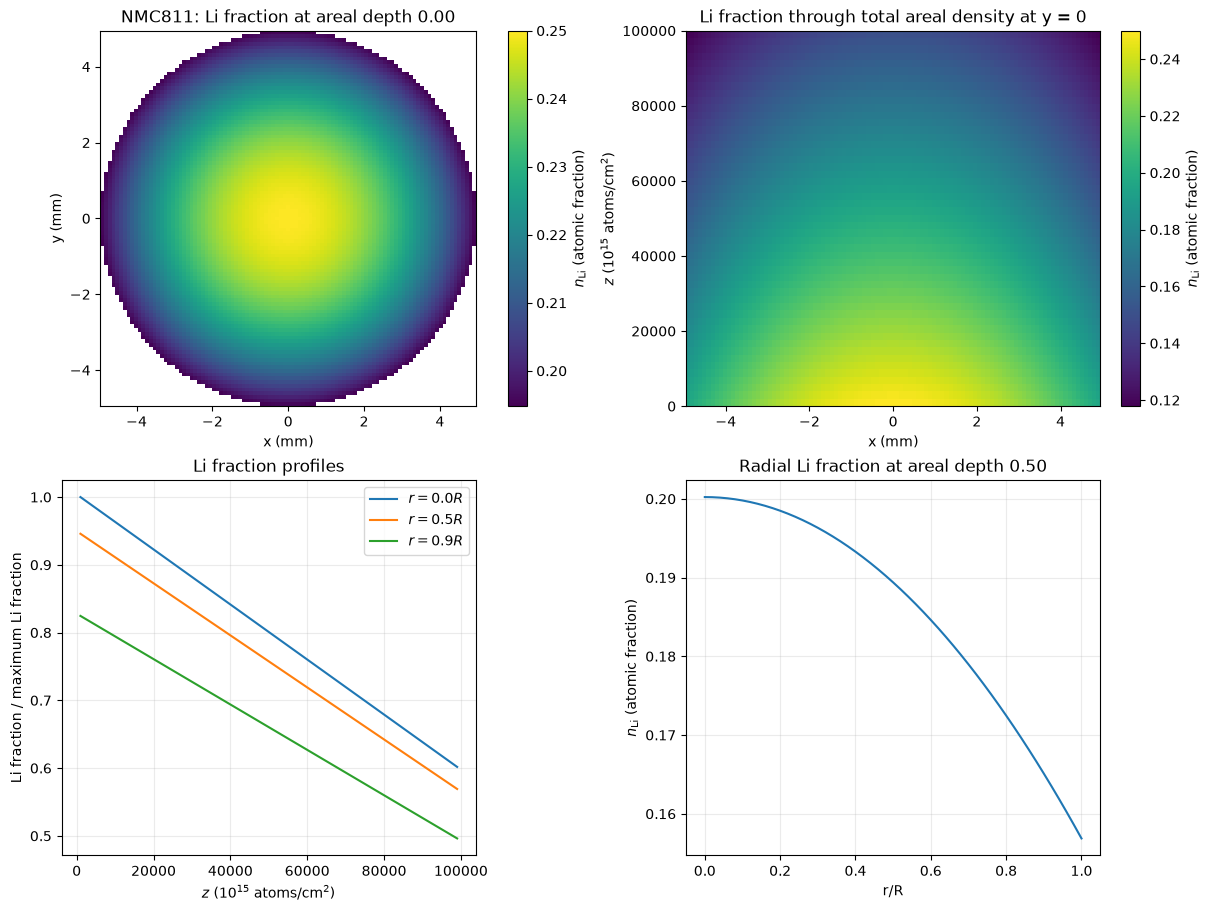

In [51]:
geometry = CircularElectrodeGeometry(
    R=5.0,
    areal_depth_max=100_000.0,  # units of 1e15 atoms/cm^2
    Nx=101,
    Ny=101,
    Nz=51,
)
example_model = NMCCathodeModel(geometry, chemistry="NMC811", kappa=0.5)
example = example_model.generate(eta=0.50)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
plot_top_view(example, z_fraction=0.0, ax=axes[0, 0])
plot_cross_section(example, ax=axes[0, 1])
plot_depth_profiles(example, ax=axes[1, 0])
plot_radial_profile(example, z_fraction=0.5, ax=axes[1, 1])
plt.show()


## Check integrated composition across electrode types, chemistries, and SOC

For each generated field, recover the global Li-to-host ratio by integrating the atomic fractions over area and total areal depth. The ratio should reproduce the requested stoichiometry and SOC. The sampled radial mode is centered under the discretized disk-area measure so the finite grid preserves the integrated target.


In [52]:
SOC_VALUES = (0.0, 0.25, 0.50, 0.75, 1.0)
SOC_TOLERANCE = 1e-10
rows = []

anode_model = AnodeModel(geometry)
for eta in SOC_VALUES:
    result = anode_model.generate(eta)
    recovered, mean_stoichiometry = calculate_anode_soc(
        result.fields["Li"], result.fields["C"], result.dA_dzA,
        anode_model.y_min, anode_model.y_max,
    )
    active = result.local_lithiation[result.mask]
    error = abs(recovered - eta)
    assert active.min() >= anode_model.y_min - 1e-10
    assert active.max() <= anode_model.y_max + 1e-10
    assert error < SOC_TOLERANCE
    rows.append({
        "electrode": "anode", "chemistry": "graphite",
        "requested_SOC": eta, "recovered_SOC": recovered, "error": error,
        "min_local_lithiation": active.min(),
        "max_local_lithiation": active.max(),
        "integrated_stoichiometry": mean_stoichiometry,
    })

for chemistry in NMC_COMPOSITIONS:
    cathode_model = NMCCathodeModel(geometry, chemistry=chemistry)
    for eta in SOC_VALUES:
        result = cathode_model.generate(eta)
        recovered, mean_stoichiometry = calculate_cathode_soc(
            result.fields["Li"], result.fields["Ni"], result.fields["Mn"],
            result.fields["Co"], result.fields["O"], result.dA_dzA,
            cathode_model.x_min, cathode_model.x_max,
        )
        active = result.local_lithiation[result.mask]
        error = abs(recovered - eta)
        assert active.min() >= cathode_model.x_min - 1e-10
        assert active.max() <= cathode_model.x_max + 1e-10
        assert error < SOC_TOLERANCE
        rows.append({
            "electrode": "cathode", "chemistry": chemistry,
            "requested_SOC": eta, "recovered_SOC": recovered, "error": error,
            "min_local_lithiation": active.min(),
            "max_local_lithiation": active.max(),
            "integrated_stoichiometry": mean_stoichiometry,
        })

validation = pd.DataFrame(rows)
validation.style.format({
    "requested_SOC": "{:.2f}", "recovered_SOC": "{:.10f}", "error": "{:.2e}",
    "min_local_lithiation": "{:.6f}", "max_local_lithiation": "{:.6f}",
    "integrated_stoichiometry": "{:.6f}",
})


,electrode,chemistry,requested_SOC,recovered_SOC,error,min_local_lithiation,max_local_lithiation,integrated_stoichiometry
0,anode,graphite,0.00,0.0000000000,0.00e+00,0.000000,0.000000,0.000000
1,anode,graphite,0.25,0.2500000000,5.55e-17,0.161823,0.357616,0.250000
2,anode,graphite,0.50,0.5000000000,0.00e+00,0.268038,0.815534,0.500000
3,anode,graphite,0.75,0.7500000000,0.00e+00,0.542933,1.000000,0.750000
4,anode,graphite,1.00,1.0000000000,2.22e-16,1.000000,1.000000,1.000000
5,cathode,NMC111,0.00,-0.0000000000,3.17e-16,1.000000,1.000000,1.000000
6,cathode,NMC111,0.25,0.2500000000,5.55e-17,0.674999,1.000000,0.825000
7,cathode,NMC111,0.50,0.5000000000,1.67e-16,0.398380,1.000000,0.650000
8,cathode,NMC111,0.75,0.7500000000,1.11e-16,0.300000,0.706438,0.475000
9,cathode,NMC111,1.00,1.0000000000,0.00e+00,0.300000,0.300000,0.300000


## Generate an NMC Li atomic-fraction field

The model creates $n_{\mathrm{Li}}=A_l(r,	heta)D_l(z)$ directly. It then distributes $1-n_{\mathrm{Li}}$ across Ni, Mn, Co, and O according to the selected NMC composition. The depth coordinate is in units of 1e15 atoms/cm^2 and spans 100,000 units for this sample.


In [53]:
chosen = NMCCathodeModel(
    geometry=geometry,
    chemistry="NMC622",
    x_min=0.3,
    x_max=1.0,
    kappa=0.5,
    w_r=1.0,
    w_z=2.0,
).generate(eta=0.75)

concentration_sum = sum(chosen.fields.values())
print("Field shapes:", {element: field.shape for element, field in chosen.fields.items()})
print("Active voxels:", int(chosen.mask.sum()))
print("Mean elemental fraction sum inside electrode:", concentration_sum[chosen.mask].mean())
print("Local Li stoichiometry range:", np.nanmin(chosen.local_lithiation), np.nanmax(chosen.local_lithiation))
print("Integrated Li:host ratio:", end=" ")
_, recovered_x = calculate_cathode_soc(
    chosen.fields["Li"], chosen.fields["Ni"], chosen.fields["Mn"],
    chosen.fields["Co"], chosen.fields["O"], chosen.dA_dzA,
    0.3, 1.0,
)
print(f"{recovered_x:.6f} Li per NMC formula unit")


Field shapes: {'Li': (51, 101, 101), 'Ni': (51, 101, 101), 'Mn': (51, 101, 101), 'Co': (51, 101, 101), 'O': (51, 101, 101)}
Active voxels: 409071
Mean elemental fraction sum inside electrode: 1.0
Local Li stoichiometry range: 0.3 0.706438499132898
Integrated Li:host ratio: 0.475000 Li per NMC formula unit


## Assemble the 4 × 5 sample holder field

The holder is an aluminum plate with 1 mm margins. Twenty 10 mm circular samples sit on an 11 mm pitch, giving 1 mm gaps. The resulting holder is 56 × 45 mm. The first row contains the shared graphite anode at the five SOC values; the remaining rows contain NMC111, NMC622, and NMC811 in that order. Aluminum fills the holder between the sample disks. Each material occupies the modeled total-areal-depth span of 100,000 units of 10¹⁵ atoms/cm².

The resulting `sample_fields` arrays store `n_i(x,y,z_A)` for Li, C, Ni, Mn, Co, O, and Al over the holder footprint. Inside each disk, the Li fraction uses the same separable radial and areal-depth profile as the individual electrode models.

The final comparison treats the fine-grid field as the reference and samples it on a 100 × 100 IBA raster across the full holder. It shows the reference heatmap, the raster samples, and a Delaunay-interpolated reconstruction so the scan resolution can be judged visually and by its reconstruction error. The aluminum holder is gray.


Sample fields: {'Li': (51, 450, 560), 'C': (51, 450, 560), 'Ni': (51, 450, 560), 'Mn': (51, 450, 560), 'Co': (51, 450, 560), 'O': (51, 450, 560), 'Al': (51, 450, 560)}
Layout: 4 rows × 5 columns; first row is the shared graphite anode
Fine reference XY grid: 560 × 450 points
Holder (mm): 56.0 × 45.0
Sample array footprint (mm): 54.0 × 43.0
Total areal depth: 100000.0 units of 1e15 atoms/cm^2
Maximum elemental-fraction closure error: 5.960464477539063e-08


,cell_id,row,row_name,column,requested_SOC,recovered_SOC,chemistry,center_x_mm,center_y_mm,local_lithiation_min,local_lithiation_max
0,0,1,Graphite anode,1,0.00,0.00,graphite,-22.0,16.5,0.000000,0.000000
1,1,1,Graphite anode,2,0.25,0.25,graphite,-11.0,16.5,0.161838,0.357616
2,2,1,Graphite anode,3,0.50,0.50,graphite,0.0,16.5,0.268075,0.815534
3,3,1,Graphite anode,4,0.75,0.75,graphite,11.0,16.5,0.542972,1.000000
4,4,1,Graphite anode,5,1.00,1.00,graphite,22.0,16.5,1.000000,1.000000
5,5,2,NMC111 cathode,1,0.00,0.00,NMC111,-22.0,5.5,1.000000,1.000000
6,6,2,NMC111 cathode,2,0.25,0.25,NMC111,-11.0,5.5,0.675028,1.000000
7,7,2,NMC111 cathode,3,0.50,0.50,NMC111,0.0,5.5,0.398422,1.000000
8,8,2,NMC111 cathode,4,0.75,0.75,NMC111,11.0,5.5,0.300000,0.706491
9,9,2,NMC111 cathode,5,1.00,1.00,NMC111,22.0,5.5,0.300000,0.300000


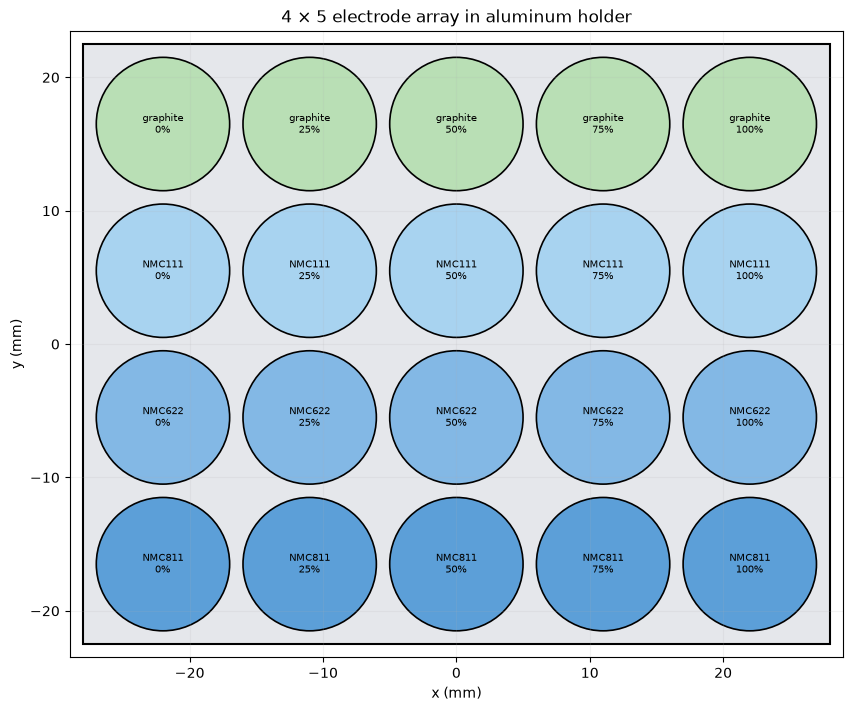

100x100 scan over 56x45 mm holder: 10,000 points
Scan pitch (mm): 0.56 x 0.45
Delaunay reconstruction over sample pixels: coverage=89.0%, MAE=9.31596e-05, RMSE=0.00016317


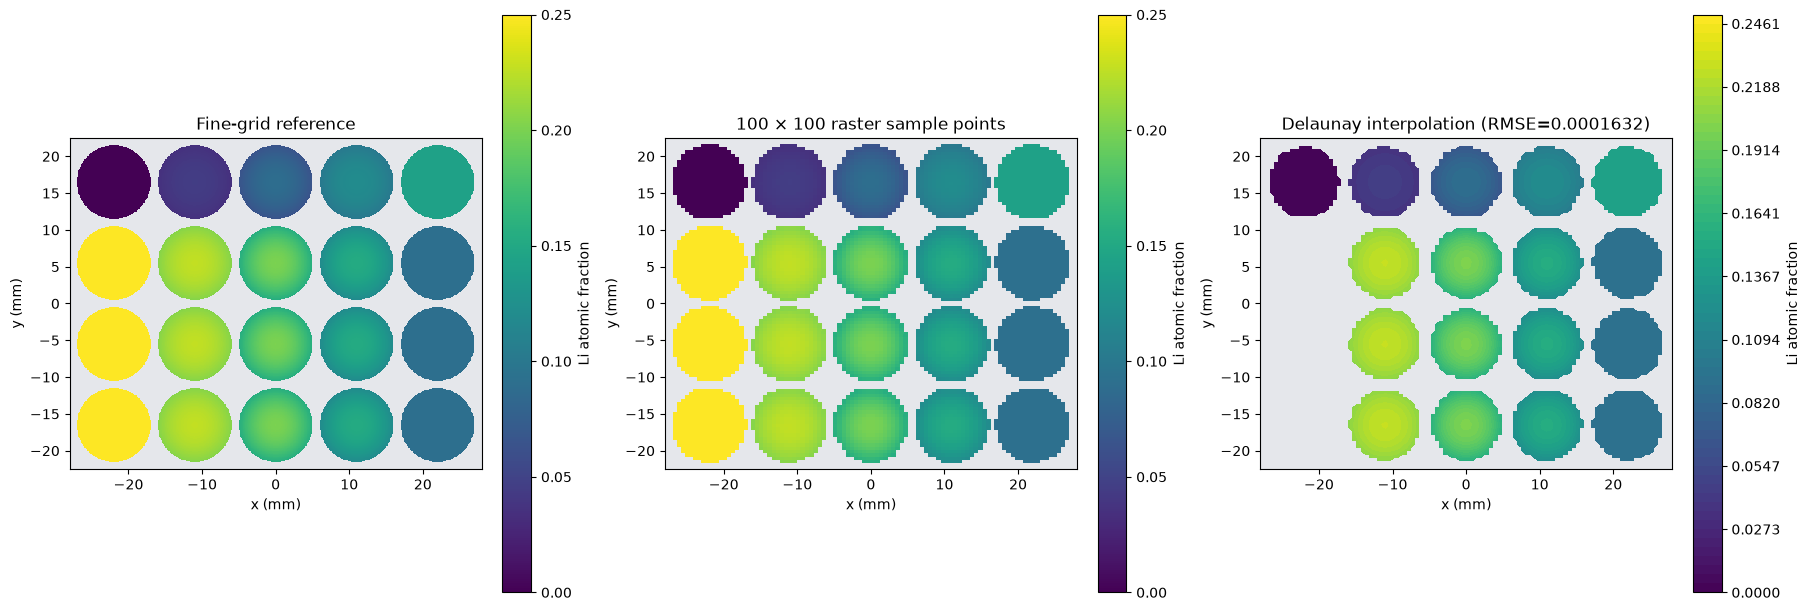

In [54]:
# Holder and cell-array dimensions (lengths in mm).
CELL_DIAMETER = 10.0
CELL_RADIUS = CELL_DIAMETER / 2.0
CELL_GAP = 1.0
HOLDER_MARGIN = 1.0
CELL_PITCH = CELL_DIAMETER + CELL_GAP
ARRAY_WIDTH = 5 * CELL_DIAMETER + 4 * CELL_GAP
ARRAY_HEIGHT = 4 * CELL_DIAMETER + 3 * CELL_GAP
HOLDER_WIDTH = ARRAY_WIDTH + 2 * HOLDER_MARGIN
HOLDER_HEIGHT = ARRAY_HEIGHT + 2 * HOLDER_MARGIN
GROUND_TRUTH_SPACING = 0.1  # mm; finer than the proposed IBA raster
ARRAY_SPACING = GROUND_TRUTH_SPACING

if not np.isclose(geometry.areal_depth_max, 100_000.0):
    raise ValueError("The 4x5 array expects a total areal depth of 100,000 units")

Nx_array = round(HOLDER_WIDTH / ARRAY_SPACING)
Ny_array = round(HOLDER_HEIGHT / ARRAY_SPACING)
if not np.isclose(Nx_array * ARRAY_SPACING, HOLDER_WIDTH) or not np.isclose(Ny_array * ARRAY_SPACING, HOLDER_HEIGHT):
    raise ValueError("ARRAY_SPACING must divide the holder dimensions")
array_x = -HOLDER_WIDTH / 2 + (np.arange(Nx_array) + 0.5) * ARRAY_SPACING
array_y = -HOLDER_HEIGHT / 2 + (np.arange(Ny_array) + 0.5) * ARRAY_SPACING
_, _, z_areal, _, _, array_f_z, _ = geometry.spatial_basis()
dA_dzA_array = ARRAY_SPACING**2 * geometry.areal_depth_max / geometry.Nz

# Row 0 is the common graphite anode; cathode rows follow in chemistry order.
row_specs = [
    {"row": 0, "name": "Graphite anode", "electrode": "anode", "chemistry": "graphite"},
    {"row": 1, "name": "NMC111 cathode", "electrode": "cathode", "chemistry": "NMC111"},
    {"row": 2, "name": "NMC622 cathode", "electrode": "cathode", "chemistry": "NMC622"},
    {"row": 3, "name": "NMC811 cathode", "electrode": "cathode", "chemistry": "NMC811"},
]
column_soc = tuple(SOC_VALUES)
column_centers = (np.arange(5) - 2) * CELL_PITCH
row_centers = (1.5 - np.arange(4)) * CELL_PITCH

# Aluminum fills the holder. Each sample disk replaces the holder composition.
element_names = ("Li", "C", "Ni", "Mn", "Co", "O", "Al")
sample_fields = {
    element: np.zeros((geometry.Nz, Ny_array, Nx_array), dtype=np.float32)
    for element in element_names
}
sample_fields["Al"][:] = 1.0
cell_id_map = np.full((Ny_array, Nx_array), -1, dtype=np.int16)
cell_records = []
cell_id = 0

for row_spec in row_specs:
    for column, eta in enumerate(column_soc):
        center_x = float(column_centers[column])
        center_y = float(row_centers[row_spec["row"]])
        x_ids = np.flatnonzero(np.abs(array_x - center_x) <= CELL_RADIUS + ARRAY_SPACING / 2)
        y_ids = np.flatnonzero(np.abs(array_y - center_y) <= CELL_RADIUS + ARRAY_SPACING / 2)
        x0, x1 = int(x_ids[0]), int(x_ids[-1]) + 1
        y0, y1 = int(y_ids[0]), int(y_ids[-1]) + 1
        local_x, local_y = array_x[x0:x1], array_y[y0:y1]
        XX, YY = np.meshgrid(local_x - center_x, local_y - center_y, indexing="xy")
        radius = np.hypot(XX, YY)
        disk_mask = radius <= CELL_RADIUS

        # Center the radial mode over this disk's actual XY pixels.
        f_r_local = 1.0 - 2.0 * (radius / CELL_RADIUS) ** 2
        f_r_local[disk_mask] -= f_r_local[disk_mask].mean()
        f_r_local /= np.max(np.abs(f_r_local[disk_mask]))
        f_r_local[~disk_mask] = 0.0
        active_3d = np.broadcast_to(disk_mask[None, :, :], (geometry.Nz, *disk_mask.shape))

        if row_spec["electrode"] == "anode":
            model = AnodeModel(geometry)
            local_l = model.y_min + eta * (model.y_max - model.y_min)
            mean_li = local_l / (local_l + 6.0)
            li_bounds = (model.y_min / (model.y_min + 6.0), model.y_max / (model.y_max + 6.0))
            host_atom_count = 6.0
        else:
            model = NMCCathodeModel(geometry, chemistry=row_spec["chemistry"])
            local_l = model.x_max - eta * (model.x_max - model.x_min)
            mean_li = local_l / (local_l + 3.0)
            li_bounds = (model.x_min / (model.x_min + 3.0), model.x_max / (model.x_max + 3.0))
            host_atom_count = 3.0

        local_n_li = build_li_fraction_profile(
            mean_li, f_r_local, array_f_z, eta,
            model.kappa, model.w_r, model.w_z, li_bounds, active_3d,
        )
        local_non_li = 1.0 - local_n_li
        if row_spec["electrode"] == "anode":
            local_fields = {"Li": local_n_li, "C": local_non_li}
            local_stoich = 6.0 * local_n_li / np.maximum(local_non_li, np.finfo(float).tiny)
        else:
            a, b, c = NMC_COMPOSITIONS[row_spec["chemistry"]]
            local_fields = {
                "Li": local_n_li,
                "Ni": (a / 3.0) * local_non_li,
                "Mn": (b / 3.0) * local_non_li,
                "Co": (c / 3.0) * local_non_li,
                "O": (2.0 / 3.0) * local_non_li,
            }
            local_stoich = 3.0 * local_n_li / np.maximum(local_non_li, np.finfo(float).tiny)

        region_id = cell_id_map[y0:y1, x0:x1]
        region_id[disk_mask] = cell_id
        for element in element_names:
            region = sample_fields[element][:, y0:y1, x0:x1]
            if element == "Al":
                region[:, disk_mask] = 0.0
            else:
                local_values = local_fields.get(element)
                if local_values is not None:
                    region[:, disk_mask] = local_values[:, disk_mask].astype(np.float32)

        li_count = float(np.sum(local_fields["Li"][:, disk_mask]) * dA_dzA_array)
        host_count = float(np.sum(local_non_li[:, disk_mask]) * dA_dzA_array)
        recovered_l = host_atom_count * li_count / host_count
        recovered_soc = (
            (recovered_l - model.y_min) / (model.y_max - model.y_min)
            if row_spec["electrode"] == "anode"
            else (model.x_max - recovered_l) / (model.x_max - model.x_min)
        )
        cell_records.append({
            "cell_id": cell_id,
            "row": row_spec["row"] + 1,
            "row_name": row_spec["name"],
            "column": column + 1,
            "requested_SOC": eta,
            "recovered_SOC": recovered_soc,
            "chemistry": row_spec["chemistry"],
            "center_x_mm": center_x,
            "center_y_mm": center_y,
            "local_lithiation_min": float(local_stoich[:, disk_mask].min()),
            "local_lithiation_max": float(local_stoich[:, disk_mask].max()),
        })
        cell_id += 1

sample_layout = pd.DataFrame(cell_records)
holder_mask = np.ones((Ny_array, Nx_array), dtype=bool)
holder_mask[cell_id_map >= 0] = False

print("Sample fields:", {element: field.shape for element, field in sample_fields.items()})
print("Layout: 4 rows × 5 columns; first row is the shared graphite anode")
print("Fine reference XY grid:", Nx_array, "×", Ny_array, "points")
print("Holder (mm):", HOLDER_WIDTH, "×", HOLDER_HEIGHT)
print("Sample array footprint (mm):", ARRAY_WIDTH, "×", ARRAY_HEIGHT)
print("Total areal depth:", geometry.areal_depth_max, "units of 1e15 atoms/cm^2")
print("Maximum elemental-fraction closure error:", float(np.max(np.abs(sum(sample_fields.values()) - 1.0))))
from IPython.display import display
display(sample_layout)

from matplotlib.patches import Circle, Rectangle

fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
ax.add_patch(Rectangle(
    (-HOLDER_WIDTH / 2, -HOLDER_HEIGHT / 2), HOLDER_WIDTH, HOLDER_HEIGHT,
    facecolor="#e5e7eb", edgecolor="black", linewidth=1.5,
))
row_colors = ("#b9dfb5", "#a8d3f0", "#83b8e5", "#5c9fd8")
for record in cell_records:
    color = row_colors[record["row"] - 1]
    ax.add_patch(Circle(
        (record["center_x_mm"], record["center_y_mm"]), CELL_RADIUS,
        facecolor=color, edgecolor="black", linewidth=1.2,
    ))
    ax.text(
        record["center_x_mm"], record["center_y_mm"],
        f"{record['chemistry']}\n{record['requested_SOC']:.0%}",
        ha="center", va="center", fontsize=7,
    )
ax.set(
    xlim=(-HOLDER_WIDTH / 2 - 1, HOLDER_WIDTH / 2 + 1),
    ylim=(-HOLDER_HEIGHT / 2 - 1, HOLDER_HEIGHT / 2 + 1),
    xlabel="x (mm)", ylabel="y (mm)",
    title="4 × 5 electrode array in aluminum holder",
)
ax.set_aspect("equal")
ax.grid(alpha=0.15)
plt.show()

# Compare the fine-grid Li field with a 100x100 IBA raster over the holder.
import matplotlib.tri as mtri

HEATMAP_AREAL_DEPTH_FRACTION = 0.5
SCAN_POINTS_X = 100
SCAN_POINTS_Y = 100
heatmap_iz = int(np.argmin(np.abs(z_areal / geometry.areal_depth_max - HEATMAP_AREAL_DEPTH_FRACTION)))
li_reference = sample_fields["Li"][heatmap_iz]
reference_mask = holder_mask

# Place scan points at the centers of a regular 100x100 raster over the holder.
scan_dx = HOLDER_WIDTH / SCAN_POINTS_X
scan_dy = HOLDER_HEIGHT / SCAN_POINTS_Y
scan_x = -HOLDER_WIDTH / 2 + (np.arange(SCAN_POINTS_X) + 0.5) * scan_dx
scan_y = -HOLDER_HEIGHT / 2 + (np.arange(SCAN_POINTS_Y) + 0.5) * scan_dy
scan_ix = np.abs(array_x[None, :] - scan_x[:, None]).argmin(axis=1)
scan_iy = np.abs(array_y[None, :] - scan_y[:, None]).argmin(axis=1)
li_scan = li_reference[np.ix_(scan_iy, scan_ix)]
scan_cell_ids = cell_id_map[np.ix_(scan_iy, scan_ix)]
scan_sample_mask = scan_cell_ids >= 0

# Matplotlib's Triangulation constructs a Delaunay triangulation. Mask triangles
# that cross sample boundaries or lie in the aluminum so interpolation stays
# within each individual electrode disk.
scan_xx, scan_yy = np.meshgrid(scan_x, scan_y)
triangulation = mtri.Triangulation(scan_xx.ravel(), scan_yy.ravel())
triangle_cell_ids = scan_cell_ids.ravel()[triangulation.triangles]
triangle_mask = np.any(triangle_cell_ids < 0, axis=1) | np.any(
    triangle_cell_ids != triangle_cell_ids[:, :1], axis=1
)
triangulation.set_mask(triangle_mask)
li_values = li_scan.ravel()
li_interpolator = mtri.LinearTriInterpolator(triangulation, li_values)
reference_xx, reference_yy = np.meshgrid(array_x, array_y)
li_reconstruction = li_interpolator(reference_xx, reference_yy)
reconstruction_mask = np.ma.getmaskarray(li_reconstruction) | reference_mask
li_reconstruction_plot = np.ma.array(li_reconstruction, mask=reconstruction_mask)
cell_pixels = ~reference_mask
valid_comparison = cell_pixels & ~reconstruction_mask
scan_rmse = float(np.sqrt(np.mean((li_reconstruction.data[valid_comparison] - li_reference[valid_comparison]) ** 2)))
scan_mae = float(np.mean(np.abs(li_reconstruction.data[valid_comparison] - li_reference[valid_comparison])))
coverage = float(valid_comparison.sum() / cell_pixels.sum())

heatmap_cmap = plt.get_cmap("viridis").copy()
heatmap_cmap.set_bad(color="#e5e7eb", alpha=1.0)
heatmap_max = float(li_reference.max())
extent = (-HOLDER_WIDTH / 2, HOLDER_WIDTH / 2, -HOLDER_HEIGHT / 2, HOLDER_HEIGHT / 2)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
reference_image = axes[0].imshow(
    np.ma.masked_where(reference_mask, li_reference), origin="lower", extent=extent,
    aspect="equal", cmap=heatmap_cmap, vmin=0.0, vmax=heatmap_max,
    interpolation="nearest",
)
axes[0].set(title="Fine-grid reference", xlabel="x (mm)", ylabel="y (mm)")
fig.colorbar(reference_image, ax=axes[0], label="Li atomic fraction")

scan_image = axes[1].scatter(
    scan_xx[scan_sample_mask], scan_yy[scan_sample_mask],
    c=li_scan[scan_sample_mask], s=13, marker="s", linewidths=0,
    cmap=heatmap_cmap, vmin=0.0, vmax=heatmap_max,
)
axes[1].set_facecolor("#e5e7eb")
axes[1].set(title="100 × 100 raster sample points", xlabel="x (mm)", ylabel="y (mm)")
fig.colorbar(scan_image, ax=axes[1], label="Li atomic fraction")

interpolated_image = axes[2].tricontourf(
    triangulation, li_values, levels=np.linspace(0.0, heatmap_max, 65),
    cmap=heatmap_cmap, vmin=0.0, vmax=heatmap_max,
)
axes[2].set_facecolor("#e5e7eb")
axes[2].set(
    title=f"Delaunay interpolation (RMSE={scan_rmse:.4g})",
    xlabel="x (mm)", ylabel="y (mm)",
)
fig.colorbar(interpolated_image, ax=axes[2], label="Li atomic fraction")
for ax in axes:
    ax.set_xlim(-HOLDER_WIDTH / 2, HOLDER_WIDTH / 2)
    ax.set_ylim(-HOLDER_HEIGHT / 2, HOLDER_HEIGHT / 2)
    ax.set_aspect("equal")
print(f"100x100 scan over {HOLDER_WIDTH:g}x{HOLDER_HEIGHT:g} mm holder: {SCAN_POINTS_X * SCAN_POINTS_Y:,} points")
print("Scan pitch (mm):", scan_dx, "x", scan_dy)
print(f"Delaunay reconstruction over sample pixels: coverage={coverage:.1%}, MAE={scan_mae:.6g}, RMSE={scan_rmse:.6g}")
plt.show()
